In [7]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax
from jax import config
config.update("jax_enable_x64", False)

In [8]:
n_states, start_width, response_width, threshold, measurement_prob, delta, mu, sigma, I, J = 7, 3, 1, 1, 1, 1, np.asarray([[2]]), np.asarray([[1]]), 1, 5
model_type, transition_type = "Markov", "TIMESTEP"

In [9]:
I = 10
mu, sigma = np.tile(1,(I,1)), np.tile(2,(I,1))
intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
phi_0 = ca._get_initial_state(n_states, start_width, response_width, model_type=model_type, prior_type="Uniform")
intensity_matrix, phi_0

(Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]],
 
 
        [[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]],
 
 
        [[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,

In [10]:
jax.jacrev(ca.get_intensity_matrix, allow_int=True)(n_states, mu, sigma, model_type).sum()

Array(0, dtype=int32)

In [11]:
Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
Mc

Array([[0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [12]:

t = np.asarray([[20]]) #t_s #
phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s=t, RA_s = None, delta=delta, 
Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
transition_type=transition_type, likelihood_type="SINGLE")

intensity_matrix.size, phi_t.size, (phi_t.size * phi_t.itemsize) / 1000000 # to get MB

(490, 70, 0.00028)

In [13]:
phi_jac = jax.jacfwd(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(490, 34300, 0.1372)

In [14]:
intensity_matrix.squeeze().shape, phi_t.squeeze().shape, phi_jac.squeeze().shape

((10, 7, 7), (10, 7), (10, 7, 10, 7, 7))

In [15]:
import jax.scipy as sci

In [16]:
ns=np.ceil(t/delta)

def perform_state_transition(intensity_matrix, RT_s, RA_s, Mc, Mw, Mn, phi_0, delta, transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT"):
     
    #ns=np.floor(RT/delta) # uncomment to include all response time
    
    T_delta = sci.linalg.expm(intensity_matrix * delta)

    # uncomment to include all response time
    # T_delta_remaining = sci.linalg.expm(intensity_matrix * ((RT_remaining[...,None,None]) if not npx.isscalar(RT_remaining) else (RT_remaining)))
    T_t = ca._timestep_transition_matrix(ns, T_delta, Mn)  #uncomment if fails
    return T_t

In [17]:
fn = jax.jacrev(perform_state_transition)
compiled = jax.jit(fn, static_argnames=["transition_type", "likelihood_type"]).lower(intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, transition_type, "SINGLE"
     )
compiled.compile().cost_analysis()

[{'optimal_seconds': -22.0,
  'bytes accessed2{}': 13945095.0,
  'bytes accessed6{}': 962564.0,
  'utilization2{}': 150.0,
  'bytes accessed10{}': 40.0,
  'utilization1{}': 252.0,
  'utilization4{}': 79.0,
  'bytes accessed4{}': 4808440.0,
  'utilization6{}': 10.0,
  'utilization3{}': 103.0,
  'flops': 50408256.0,
  'bytes accessed5{}': 2885790.0,
  'bytes accessed8{}': 960400.0,
  'bytes accessed0{}': 43343296.0,
  'utilization11{}': 1.0,
  'bytes accessed3{}': 7688384.0,
  'transcendentals': 20.0,
  'utilization9{}': 1.0,
  'bytes accessed1{}': 31068576.0,
  'utilization0{}': 362.5714416503906,
  'bytes accessed11{}': 4.0,
  'utilization8{}': 1.0,
  'bytes accessed9{}': 960400.0,
  'utilization5{}': 19.0,
  'utilization10{}': 1.0,
  'bytes accessedout{}': 50457332.0,
  'bytes accessed7{}': 960520.0,
  'bytes accessed': 152436048.0,
  'utilization7{}': 6.0}]

In [18]:
phi_jac = jax.jacrev(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(490, 34300, 0.1372)

In [19]:
intensity_matrix.shape, phi_jac.shape

((10, 1, 7, 7), (10, 1, 7, 1, 10, 1, 7, 7))

In [20]:
jax.jacfwd(jax.jacrev(ca.perform_state_transition))\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE").size

16807000

In [21]:
likl = ca.likelihood(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type)
likl.shape

(10, 1)

In [22]:

likl = jax.jacrev(ca.likelihood)(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type)
likl.shape

(10, 1, 10, 1, 7, 7)

In [23]:
likl_lower = jax.jacrev(ca.likelihood)(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type)

In [24]:
import jax.numpy as npx
def likelihood(intensity_matrix, phi_0, delta, RT_s, RA_s, Mc, Mw, Mn, transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT", model_type="Markov|Quantum"):

    phi_t = perform_state_transition(intensity_matrix, RT_s, RA_s, Mc, Mw, Mn, phi_0, delta, 
                                     transition_type=transition_type, likelihood_type=likelihood_type)

    if likelihood_type == "SINGLE":
        RA = RA_s
        RT_cond = RT_s
    else:
        raise Exception(f"Please select one of {likelihood_type} values for likelihood_type variable")


    P_t_c = (Mc @ phi_t)
    P_t_w = (Mw @ phi_t)
    P_t = npx.where(RA[...,None,None]==1, P_t_c, P_t_w)

    if model_type == "Markov":
        #P_t_c = (Mc @ phi_t).sum(axis=(-2,-1))
        #P_t_w = (Mw @ phi_t).sum(axis=(-2,-1))

        P_t = P_t.sum(axis=(-2,-1)) # Adding over states
        
        #P_t = npx.where(RA==1, P_t_c, P_t_w)
        
    elif model_type == "Quantum":
        #P_t_c = (npx.abs(Mc @ phi_t)**2).sum(axis=(-2,-1))
        #P_t_w = (npx.abs(Mw @ phi_t)**2).sum(axis=(-2,-1))

        P_t = (npx.abs(P_t)**2).sum(axis=(-2,-1)) #Adding over states
        

        #P_t = npx.where(RA==1, P_t_c, P_t_w)
        
    else:
        raise Exception(f"Please select one of {model_type}")
  
    
    P_t = npx.where(RT_cond <= 0, 0, P_t)

    return npx.log(P_t).sum() #npx.log(npx.sum(P_t)) # summing over all participants and trials

In [25]:
fn = jax.grad(likelihood)
cost = jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).compile().cost_analysis()
cost

[{'utilization10{}': 1.0,
  'utilization5{}': 17.0,
  'bytes accessed9{}': 40.0,
  'utilization8{}': 1.0,
  'bytes accessed11{}': 4.0,
  'utilization0{}': 327.57147216796875,
  'bytes accessed1{}': 165805.0,
  'utilization7{}': 5.0,
  'bytes accessed': 808283.0,
  'bytes accessedout{}': 312257.0,
  'bytes accessed7{}': 2040.0,
  'bytes accessed4{}': 12156.0,
  'utilization4{}': 72.0,
  'utilization1{}': 247.0,
  'utilization2{}': 142.0,
  'bytes accessed6{}': 4044.0,
  'bytes accessed2{}': 92375.0,
  'bytes accessed10{}': 40.0,
  'optimal_seconds': -1.0,
  'transcendentals': 20.0,
  'utilization9{}': 1.0,
  'bytes accessed3{}': 14744.0,
  'utilization11{}': 1.0,
  'bytes accessed0{}': 243136.0,
  'flops': 360505.0,
  'utilization3{}': 94.0,
  'utilization6{}': 8.0,
  'bytes accessed5{}': 8434.0,
  'bytes accessed8{}': 1960.0}]

In [26]:
str1 = jax.make_jaxpr(fn,static_argnums=[8,9,10])(intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     )
len(str1.pretty_print())

90962

In [27]:
fn_j = jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     )
jax.tree.leaves(fn)


[<function __main__.likelihood(intensity_matrix, phi_0, delta, RT_s, RA_s, Mc, Mw, Mn, transition_type='RT|TIMESTEP', likelihood_type='SINGLE|JOINT', model_type='Markov|Quantum')>]

In [28]:
def _get_step_size(alpha, tau, sigma):
   return alpha * npx.sqrt(sigma) * npx.sqrt(tau)

def _get_n_states(alpha, theta, tau, sigma):
    #sigma = npx.sqrt(sigma)#.squeeze()
    step_size = _get_step_size(alpha, tau, sigma)
    n_states = 2 * int(theta/step_size) + 1 #np.round(theta/delta_state) #2 * round(theta/delta_state) + 1 # #
    return n_states

In [29]:
def _create_Wiener_Q(n_states, alpha, tau, sigma, mu):
    #if mu > sigma:
    #   raise Exception("Drift Rate (mu) should be smaller than Diffusion Rate (sigma)")
    Q = npx.zeros((n_states, n_states))
    rows_ = npx.arange(1,n_states)
    cols_ = npx.arange(0,n_states-1)
    Q = Q.at[rows_,cols_].set(1/(2*alpha)*(1-mu*npx.sqrt(tau)/sigma**2))
    Q = Q.at[cols_, rows_].set(1/(2*alpha)*(1+mu*npx.sqrt(tau)/sigma**2))
    Q = Q.at[npx.arange(n_states), npx.arange(n_states)].set(1-(1/alpha))
    Q = Q.at[0,1].set(0)
    Q = Q.at[-1,-2].set(0)
    return Q

In [30]:
def disc_likl(n_states, dis_tran, initial_state):
    m = n_states-1
    #P  = npx.eye(2)
    R = dis_tran[...,1:m, [0, -1]]
    Q = dis_tran[...,1:n_states-1, 1:n_states-1]
    #Z = stats.uniform().rvs((1,Q.shape[0]))
    #Z = Z/Z.sum()
    num_arr_i = []
    
    for i_s_i, n_i, Q_i, R_i in zip(initial_state, ns1, Q, R): #global variable
        num_arr_ij = []
        for n_ij in n_i:
            num = npx.array(i_s_i[0]) @ npx.linalg.matrix_power(Q_i[0], n_ij) @ R_i[0]
            num_arr_ij.append(num)
        num_arr_i.append(num_arr_ij)

    num = npx.asarray(num_arr_i)
    den = initial_state @ npx.linalg.matrix_power(npx.eye(n_states-2) - Q, -1) @ R
    #return npx.log(num/den).sum()
    return num/den

In [31]:
theta, alpha, tau, I, J = 11, 1.5, 0.01, 10, 50

mu, sigma = npx.asarray([1.2]), npx.asarray([1])

n_states = _get_n_states(alpha, theta, tau, sigma[0])
dis_tran = _create_Wiener_Q(n_states, alpha, tau, sigma[0], mu)
dis_tran.shape

(147, 147)

In [32]:
def create_Q(I, n_states,alpha, tau, sigma, mus):
    Q = []
    for _, mu in zip(range(I),mus):
        Q.append(_create_Wiener_Q(n_states,alpha, tau, sigma, mu))
    return np.stack(Q)[:,None,...]
mus = np.tile(1.2,(I,1))
Q = create_Q(I, n_states,alpha, tau, sigma, mus)
Q.shape 

(10, 1, 147, 147)

In [33]:
stats.uniform().rvs((I,1,1,n_states-2)).shape

(10, 1, 1, 145)

In [34]:
ns1 = np.ceil(np.tile(1.2,(I,J)) / tau).astype(int)

def dis_likl(n_states, Q, initial_state):
    arr = disc_likl(n_states, Q, initial_state)
    return (npx.asarray(arr))#.sum()
fn_disc_likl = dis_likl(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2)))

fn_disc_likl.sum()

Array(1.0387748, dtype=float32)

#dis_tran = _create_Wiener_Q(n_states,alpha, tau, sigma, mu)
mu, sigma = npx.asarray([1.2]), npx.asarray([1])
fn_disc = jax.jacrev(_create_Wiener_Q, allow_int=True)

#fn_disc(n, n_states, dis_tran, stats.uniform().rvs((1,n_states-2)))#.shape
fn_disc(n_states,alpha, tau, sigma, mu).sum()

jax.tree.leaves(fn_disc)

In [35]:
fn_disc = jax.jacrev(dis_likl, allow_int=True)
fn_disc(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2))).sum()


Array(0, dtype=int32)

In [36]:
jax.jit(fn_disc, static_argnums=[0]).lower(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2))).cost_analysis()

{'bytes accessed': 4004.0,
 'utilization0{}': 1.0,
 'bytes accessed0{}': 4.0,
 'bytes accessedout{}': 4000.0}

In [37]:
ns1 = np.ceil(np.tile(1.2,(I,J)) / tau).astype(int)

jax.jit(dis_likl, static_argnums=[0]).lower(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2))).cost_analysis()

{'flops': 27582078976.0,
 'bytes accessed': 1296445440.0,
 'optimal_seconds': -1.0,
 'utilization0{}': 7644.0087890625,
 'utilization1{}': 5565.0,
 'bytes accessed0{}': 433810400.0,
 'bytes accessed1{}': 425505184.0,
 'bytes accessedout{}': 437095744.0,
 'bytes accessed30{}': 80.0,
 'bytes accessed45{}': 80.0,
 'bytes accessed23{}': 80.0,
 'bytes accessed29{}': 80.0,
 'utilization47{}': 10.0,
 'utilization20{}': 10.0,
 'bytes accessed22{}': 80.0,
 'bytes accessed7{}': 480.0,
 'utilization22{}': 10.0,
 'bytes accessed16{}': 80.0,
 'bytes accessed9{}': 480.0,
 'utilization8{}': 11.0,
 'bytes accessed18{}': 80.0,
 'bytes accessed13{}': 80.0,
 'bytes accessed39{}': 80.0,
 'utilization19{}': 10.0,
 'bytes accessed38{}': 80.0,
 'utilization44{}': 10.0,
 'bytes accessed11{}': 80.0,
 'bytes accessed27{}': 80.0,
 'utilization32{}': 10.0,
 'bytes accessed25{}': 80.0,
 'utilization9{}': 11.0,
 'utilization15{}': 10.0,
 'utilization41{}': 10.0,
 'utilization24{}': 10.0,
 'utilization48{}': 10.0,
 

# Discrete Model

In [38]:
import itertools as iter
n_states_arr, start_width_arr, measurement_prob,  = [11, 51, 101], [2, 7, 11], 0.8
#threshold, measurement_prob, drift_rate, diffusion_rate = 1, 1, np.tile(1,(I,1)), np.tile(2,(I,1))
#model_type = "Quantum"
#transition_type="RT"
I_arr, J_arr = [100], [50] #,1000,10000 I = [20, 400]
transition_type_arr = ["TIMESTEP"]#, "TIMESTEP"]
model_type_arr = ["Markov"]
df_memory1 = []
#mu, sigma = npx.asarray([1.2]), npx.asarray([1])
for (n_states, start_width), (I, J, transition_type, model_type) in iter.product(zip(n_states_arr, start_width_arr), iter.product(I_arr, J_arr, transition_type_arr, model_type_arr)):
    print(n_states, start_width, I, J, transition_type, model_type)
    mus, sigma = np.tile(1.2,(I,1)), npx.asarray([1])

    theta, alpha, tau = n_states, 1.5, 0.1

    n_states = _get_n_states(alpha, theta, tau, sigma[0])
    Q = create_Q(I, n_states,alpha, tau, sigma, mus)
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    ns1 = np.ceil(random_ts / tau).astype(int)

    #fn_g = jax.jacrev(dis_likl, allow_int=True)
    #random_ts = dist.Uniform(tau, 40/tau).sample(key=cu.get_rng(), sample_shape=(I,J))
    #ns1 = np.ceil(random_ts/tau).astype(int) #1 sec
    #cost_st_tr_g = jax.jit(fn_g, static_argnums=[0,1,2,3,4]).lower(I, J, n_states, alpha, tau, sigma[0], mu, stats.uniform().rvs((1,n_states-2))).cost_analysis()

    fn = dis_likl
    cost_st_tr = jax.jit(dis_likl, static_argnums=[0]).lower(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2))).cost_analysis()


    df_t1 = pd.DataFrame({  
        "Model":model_type,
        "Transition":"External" if transition_type == "RT" else "Internal",
        "I":I,
        "J":J,
        #"States":f"{theta}({n_states})",
        "States":f"{theta}",
        "Calculated_States":f"{n_states}",
        #"bytes_accessed_g": 0, #[cost_st_tr_g["bytes accessed"] / 1000000000], # to get GB
        #"flops_g": [cost_st_tr_g["flops"]/ 1000000000] , # to get gigaflops

        "bytes_accessed": [cost_st_tr["bytes accessed"] / 1000000000], # to get GB
        "flops": [cost_st_tr["flops"]/ 1000000000] , # to get gigaflops

    #    "matrix_orig":[intensity_matrix.size], 
    #    "matrix_jac":[phi_jac.size], 
    #    "matrix_memory":[(intensity_matrix.size * phi_jac.itemsize) / 1000000],
    #    "jac_memory":[(phi_jac.size * phi_jac.itemsize) / 1000000] # to get MB
    })
    print(cost_st_tr["bytes accessed"] / 1000000000)#, cost_st_tr_g["bytes accessed"] / 1000000000)
    #print(intensity_matrix.size, phi_jac.size)
    df_memory1.append(df_t1)
df_memory1 = pd.concat(df_memory1).assign(state="Discrete")
df_memory1

11 2 100 50 TIMESTEP Markov
1.386875392
51 7 100 50 TIMESTEP Markov
30.925058048
101 11 100 50 TIMESTEP Markov
121.587613696


,Model,Transition,I,J,States,Calculated_States,bytes_accessed,flops,state
0,Markov,Internal,100,50,11,47,1.386875,9.247370,Discrete
0,Markov,Internal,100,50,51,215,30.925058,980.737720,Discrete
0,Markov,Internal,100,50,101,425,121.587614,7659.542544,Discrete


with sns.plotting_context("talk", font_scale=1.3):
    f = sns.catplot(
                df_memory1.query("Model=='Markov'").melt(id_vars=df_memory1.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"bytes_accessed_g":"Likelihood Gradient", "bytes_accessed":"Likelihood"})})
                .assign(I = lambda df: df.I.astype(str), value = lambda df: np.ceil(df.value)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3, col_order=["Likelihood"],#, "Likelihood Gradient"],
    kind="bar", #facet_kws={"sharey":True}
    )
    #f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    #f.refline(y=1000, alpha=0.5)
    #f.refline(y=100, alpha=0.5)
    #f.refline(y=40)
    f.legend.set_title("Participants")
    #f.legend.set_bbox_to_anchor((0.25,0.6))
    f.legend.set_alpha(.1)
    f.legend.set_frame_on(True)

    
    #f.axes[0,0].text(y=120, x=2, s="100 GB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=1200, x=2.175, s="1 TB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=45, x=1.1, s="NVIDIA RTX A6000 (40 GB)", alpha=0.5, size=14)

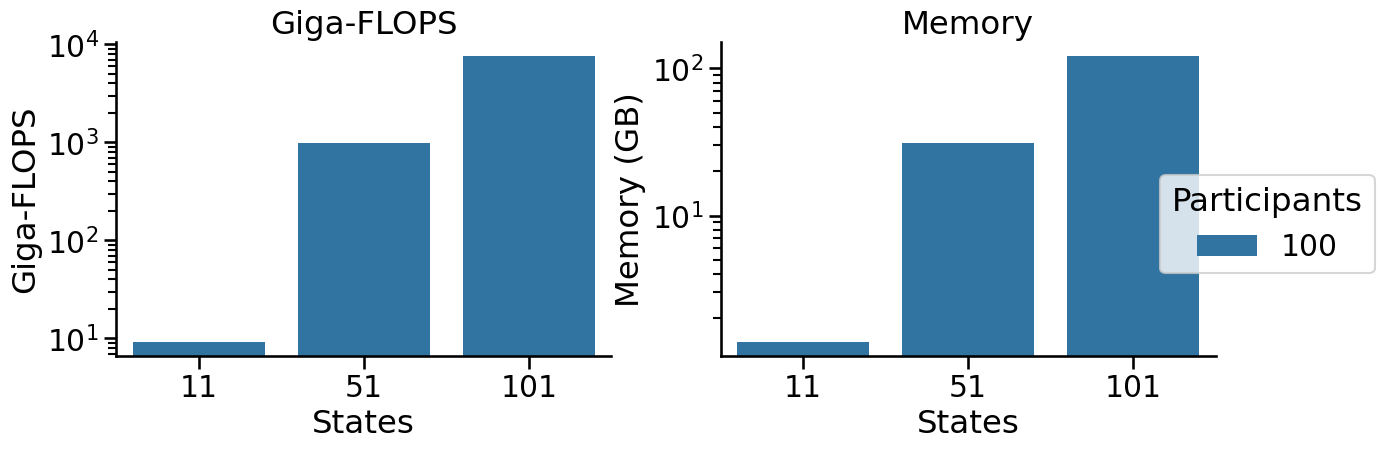

In [39]:
with sns.plotting_context("talk", font_scale=1.3):
    f = sns.catplot(
                df_memory1.query("Model=='Markov'").melt(id_vars=df_memory1.columns.drop(["flops", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"flops":"Giga-FLOPS", "bytes_accessed":"Memory"})})
                .assign(I = lambda df: df.I.astype(str)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3, col_order=["Giga-FLOPS", "Memory"],#, "Likelihood Gradient"],
    kind="bar", sharey=False,
    )
    f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Giga-FLOPS", clear_inner=False)
    f.axes[0,1].set_ylabel("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    #f.refline(y=1000, alpha=0.5)
    #f.refline(y=100, alpha=0.5)
    #f.refline(y=40)
    f.legend.set_title("Participants")
    #f.legend.set_bbox_to_anchor((0.25,0.6))
    f.legend.set_alpha(.1)
    f.legend.set_frame_on(True)

    
    #f.axes[0,0].text(y=120, x=2, s="100 GB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=1200, x=2.175, s="1 TB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=45, x=1.1, s="NVIDIA RTX A6000 (40 GB)", alpha=0.5, size=14)

In [84]:
p_s = perform_state_transition
likl = likelihood
import itertools as iter
n_states_arr, rw, start_width_arr, delta, measurement_prob,  = [21, 51, 101], [2, 5, 10], [3, 7, 11], 0.5, 0.8
threshold, measurement_prob, drift_rate, diffusion_rate = 1, 1, np.tile(1,(I,1)), np.tile(2,(I,1))
#model_type = "Quantum"
#transition_type="RT"
I_arr, J_arr = [500], [50] #,1000,10000  I= [20, 400]
transition_type_arr = ["TIMESTEP"]#, "TIMESTEP"]
model_type_arr = ["Markov", "Quantum"]
df_memory = []
for (n_states, start_width, rw), (I, J, transition_type, model_type) in iter.product(zip(n_states_arr, start_width_arr, rw), iter.product(I_arr, J_arr, transition_type_arr, model_type_arr)):
    print(n_states, start_width, I, J, transition_type, model_type)
    
    mu, sigma = np.tile(1,(I,1)), np.tile(2,(I,1))
    Mc, Mw, Mn = ca._get_measurement_matrix(n_states, response_width = rw, prob=measurement_prob, model_type = model_type)
    Mid1 = (ns-2*rw)//2
    phi_0 = ca._get_initial_state(n_states, Mid1-1, rw, model_type=model_type, prior_type="Uniform")
    
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    
    #fn_g = jax.jacrev(perform_state_transition, holomorphic=True if model_type=="Quantum" else False)
    #fn_g_jit = jax.jit(fn_g, static_argnames=["delta", "transition_type", "likelihood_type"])
    #cost_st_tr_g = fn_g_jit.lower(intensity_matrix, t, None, 
    #        Mc, Mw, Mn, 
    #        phi_0, delta, transition_type, "SINGLE"
    #        ).cost_analysis()
    ns=np.ceil(random_ts/delta)
    fn_g = jax.grad(likl)#, holomorphic=True if model_type == "Quantum" else False)
    cost_st_tr_g = jax.jit(fn_g, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, random_ts,#t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).cost_analysis()#.compile()[0]

    
    # fn_s = p_s
    # fn_s_jit = jax.jit(fn_s, static_argnames=["delta", "transition_type", "likelihood_type"])
    # cost_st_tr_s = fn_s_jit.lower(intensity_matrix, random_ts, #t, 
    #                               None, 
    #                                 Mc, Mw, Mn, 
    #                                 phi_0, delta, transition_type, "SINGLE"
    #                                 ).cost_analysis() #.compile()[0] 

    fn = likl
    cost_st_tr = jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, random_ts, #t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).cost_analysis()#.compile()[0]


    df_t = pd.DataFrame({  
        "Model":model_type,
        "Transition":"External" if transition_type == "RT" else "Internal",
        "I":I,
        "J":J,
        "States":n_states,
        "bytes_accessed_g": [cost_st_tr_g["bytes accessed"] / 1000000000], # to get GB
        "flops_g": [cost_st_tr_g["flops"]/ 1000000000] , # to get gigaflops

        #"bytes_accessed_s": [cost_st_tr_s["bytes accessed"] / 1000000000], # to get GB
        #"flops_s": [cost_st_tr_s["flops"]/ 1000000000] , # to get gigaflops

        "bytes_accessed": [cost_st_tr["bytes accessed"] / 1000000000], # to get GB
        "flops": [cost_st_tr["flops"]/ 1000000000] , # to get gigaflops

    #    "matrix_orig":[intensity_matrix.size], 
    #    "matrix_jac":[phi_jac.size], 
    #    "matrix_memory":[(intensity_matrix.size * phi_jac.itemsize) / 1000000],
    #    "jac_memory":[(phi_jac.size * phi_jac.itemsize) / 1000000] # to get MB
    })
    print(cost_st_tr["bytes accessed"] / 1000000000, cost_st_tr_g["bytes accessed"] / 1000000000)
    #print(intensity_matrix.size, phi_jac.size)
    df_memory.append(df_t)
df_memory = pd.concat(df_memory).assign(state="Continuous")
df_memory

21 3 500 50 TIMESTEP Markov
2.2685632 9.32857344
21 3 500 50 TIMESTEP Quantum
4.864036864 21.360785408
51 7 500 50 TIMESTEP Markov
13.358221312 55.044165632
51 7 500 50 TIMESTEP Quantum
28.619440128 126.162583552
101 11 500 50 TIMESTEP Markov
52.455170048 215.672061952
101 11 500 50 TIMESTEP Quantum
112.234446848 494.469808128


,Model,Transition,I,J,States,bytes_accessed_g,flops_g,bytes_accessed,flops,state
0,Markov,Internal,500,50,21,9.328573,15.837044,2.268563,5.684540,Continuous
0,Quantum,Internal,500,50,21,21.360785,16.021594,4.864037,5.724239,Continuous
0,Markov,Internal,500,50,51,55.044166,224.578929,13.358221,81.126932,Continuous
0,Quantum,Internal,500,50,51,126.162584,225.592082,28.619440,81.321869,Continuous
0,Markov,Internal,500,50,101,215.672062,1739.224777,52.455170,630.321906,Continuous
0,Quantum,Internal,500,50,101,494.469808,1745.767891,112.234447,629.185184,Continuous


In [85]:
(
    df_memory.assign(Model = lambda df: df.Model.map({"Markov":"Diffusion", "Quantum":"Quantum"}))
    .melt(id_vars = df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed", "flops_g", "flops"]))
    .assign(type = lambda df:np.where(df.variable.str.contains("_g"), "Gradient", "Likelihood"),
            variable = lambda df:df.variable.str.replace("_g","")
    )
)

,Model,Transition,I,J,States,state,variable,value,type
0,Diffusion,Internal,500,50,21,Continuous,bytes_accessed,9.328573,Gradient
1,Quantum,Internal,500,50,21,Continuous,bytes_accessed,21.360785,Gradient
2,Diffusion,Internal,500,50,51,Continuous,bytes_accessed,55.044166,Gradient
3,Quantum,Internal,500,50,51,Continuous,bytes_accessed,126.162584,Gradient
4,Diffusion,Internal,500,50,101,Continuous,bytes_accessed,215.672062,Gradient
5,Quantum,Internal,500,50,101,Continuous,bytes_accessed,494.469808,Gradient
6,Diffusion,Internal,500,50,21,Continuous,flops,15.837044,Gradient
7,Quantum,Internal,500,50,21,Continuous,flops,16.021594,Gradient
8,Diffusion,Internal,500,50,51,Continuous,flops,224.578929,Gradient
9,Quantum,Internal,500,50,51,Continuous,flops,225.592082,Gradient


(3.860465820452534, 1000)

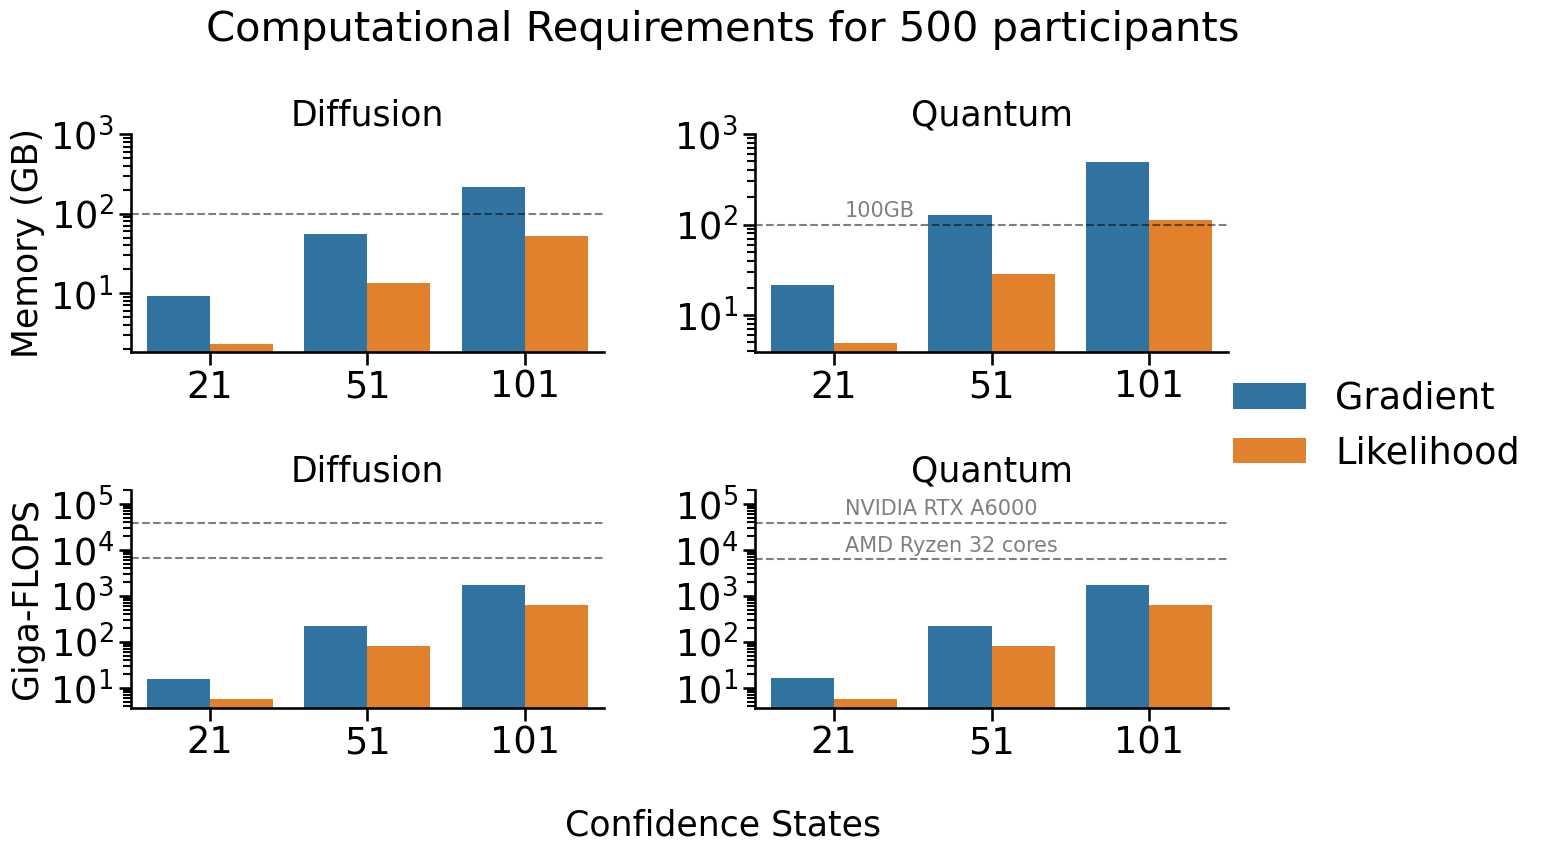

In [89]:
df_t = df_memory.assign(Model = lambda df: df.Model.map({"Markov":"Diffusion", "Quantum":"Quantum"})).melt(id_vars=df_memory.columns.drop(["flops", "bytes_accessed"])).astype({"States":"category", "I":"category"})

df_t = (
    df_memory.assign(Model = lambda df: df.Model.map({"Markov":"Diffusion", "Quantum":"Quantum"}))
    .melt(id_vars = df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed", "flops_g", "flops"]))
    .assign(type = lambda df:np.where(df.variable.str.contains("_g"), "Gradient", "Likelihood"),
            variable = lambda df:df.variable.str.replace("_g","")
    )
)

with sns.plotting_context("talk", font_scale=1.6):
    f = sns.catplot(df_t, 
            #hue="I", 
            x="States", y="value", row="variable", col="Model",
            kind="bar", sharex=False, sharey=False, 
            hue = "type", aspect=1.7, height=4,
            )
f.set(yscale="log")
f.legend.set_title("")
f.set_xlabels("")
f.axes[0,0].set_ylabel("Memory (GB)", size=25)
f.axes[1,0].set_ylabel("Giga-FLOPS", size=25)
f.set_titles("{col_name}", size=25)
f.figure.supxlabel("Confidence States", size=25)
f.figure.suptitle(f"Computational Requirements for {df_t.I.unique()[0]} participants", size=30, y=1.05)

f.axes[1,1].text(y=38.71*1500, x=.07, s="NVIDIA RTX A6000", alpha=0.5, size=15) #https://www.techpowerup.com/gpu-specs/rtx-a6000.c3686 
f.axes[1,1].text(y=8900, x=.07, s="AMD Ryzen 32 cores", alpha=0.5, size=15) #https://www.techpowerup.com/cpu-specs/ryzen-threadripper-pro-3975wx.c2315#:~:text=6%2C451.2,GFLOPS


f.axes[1,0].axhline(y=38.71*1000, ls="--", alpha=0.5, color="black") #38.71 TFLOPS
f.axes[1,0].axhline(y=6451.2, ls="--", alpha=0.5, color="black") # AMD Threadripper
f.axes[1,1].axhline(y=38.71*1000, ls="--", alpha=0.5, color="black") #38.71 TFLOPS
f.axes[1,1].axhline(y=6451.2, ls="--", alpha=0.5, color="black") # AMD Threadripper

f.axes[1,0].set_ylim((None, 200000))
f.axes[1,1].set_ylim((None, 200000))



f.axes[0,0].axhline(y=100, ls="--", alpha=0.5, color="black")
f.axes[0,1].axhline(y=100, ls="--", alpha=0.5, color="black")
f.axes[0,1].text(x=.07, y=120, s="100GB", alpha=0.5, color="black", size=15)
f.axes[0,0].set_ylim((None, 1000))
f.axes[0,1].set_ylim((None, 1000))

phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    phi_jac = jax.jacfwd(ca.perform_state_transition, holomorphic=True if model_type=="Quantum" else False)(intensity_matrix, random_ts, None, delta, 
    Mc, Mn, Mw, phi_0, transition_type, "SINGLE")

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Memory(GB)") \
            .assign(**{"Memory(GB)": lambda df: df["Memory(GB)"].map({"bytes_accessed_g":"Jacobian of Transition Fn", "bytes_accessed":"Transition Function"})})
            ,
style="States",
y="value",
col="Model",
x="I",
hue="Memory(GB)",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log", xscale="log")
f.set_ylabels("Memory (GB)")
f.set_xlabels("Number of Participants")
f.set_titles(col_template="{col_name}")

with sns.plotting_context("talk", font_scale=1.3):
    f = sns.catplot(
                df_memory.query("Model=='Quantum'").melt(id_vars=df_memory.columns.drop(["bytes_accessed_s", "bytes_accessed_g", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"bytes_accessed_s":"Transition", "bytes_accessed_g":"Likelihood Gradient", "bytes_accessed":"Likelihood"})})
                .assign(I = lambda df: df.I.astype("str"), value = lambda df: np.ceil(df.value)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3, col_order=["Likelihood", "Likelihood Gradient"],
    kind="bar", #facet_kws={"sharey":True}
    )
    #f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    #f.refline(y=1000, alpha=0.5)
    #f.refline(y=50, alpha=0.5)
    #f.refline(y=40)
    f.legend.set_title("Participants")
    f.legend.set_bbox_to_anchor((0.25,0.6))
    f.legend.set_alpha(.2)
    f.legend.set_frame_on(True)

    
    #f.axes[0,0].text(y=55, x=2, s="50 GB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=1200, x=2.175, s="1 TB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=45, x=1.1, s="NVIDIA RTX A6000 (40 GB)", alpha=0.5, size=14)

with sns.plotting_context("talk", font_scale=1.4):
    f = sns.catplot(
                df_memory.query("Model=='Quantum'").melt(id_vars=df_memory.columns.drop(["flops_g", "flops_s", "flops"]), var_name="FLOPS") \
                .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Likelihood Gradient", "flops":"Likelihood", "flops_s":"Transition Function"})) 
                .assign(I = lambda df: df.I.astype(str))
                ,
    x="States",
    y="value",
    hue="I", col_order=["Likelihood", "Likelihood Gradient"],
    col="FLOPS",
    kind="bar", aspect=1.5, legend=False
    )
    f.set(yscale="log")
    f.set_ylabels("Giga FLOPS")
    f.set_xlabels("States")
    f.set_titles(col_template="")
    f.refline(y=38.71*1000) #38.71 TFLOPS
    f.refline(y=6451.2) # AMD Threadripper
    #f.legend.set_title("Participants")
    f.axes[0,0].text(y=38.71*1500, x=1.27, s="NVIDIA RTX A6000", alpha=0.5, size=14) #https://www.techpowerup.com/gpu-specs/rtx-a6000.c3686 
    f.axes[0,0].text(y=8900, x=1.27, s="AMD Ryzen 32 cores", alpha=0.5, size=14) #https://www.techpowerup.com/cpu-specs/ryzen-threadripper-pro-3975wx.c2315#:~:text=6%2C451.2,GFLOPS

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["flops_g", "flops"]), var_name="FLOPS") \
            .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Jacobian of Transition Fn", "flops":"Transition Function"})) 
            ,
style="States",
y="value",
col="Model",
x="I",
hue="FLOPS",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log")

In [44]:
df_memory_plot = pd.concat([df_memory.assign(state="Continuous"), df_memory1.assign(state="Discrete")])
df_memory_plot

,Model,Transition,I,J,States,bytes_accessed_g,flops_g,bytes_accessed,flops,state,Calculated_States
0,Markov,Internal,100,50,11,0.430812,0.458747,0.124883,0.164399,Continuous,NaN
0,Quantum,Internal,100,50,11,1.008331,0.467841,0.266933,0.166021,Continuous,NaN
0,Markov,Internal,100,50,51,9.239818,44.838670,2.674395,16.237991,Continuous,NaN
0,Quantum,Internal,100,50,51,21.659568,45.022102,5.730122,16.268838,Continuous,NaN
0,Markov,Internal,100,50,101,36.212453,347.045495,10.478979,125.887250,Continuous,NaN
0,Quantum,Internal,100,50,101,85.112627,348.726559,22.499250,126.325088,Continuous,NaN
0,Markov,Internal,100,50,11,NaN,NaN,1.386875,9.247370,Discrete,47
0,Markov,Internal,100,50,51,NaN,NaN,30.925058,980.737720,Discrete,215
0,Markov,Internal,100,50,101,NaN,NaN,121.587614,7659.542544,Discrete,425


In [45]:
#df_memory_plot.to_csv("memory_plot_0_5_0_1.csv")
df_memory_plot = pd.read_csv("memory_plot_0_5_0_1.csv")

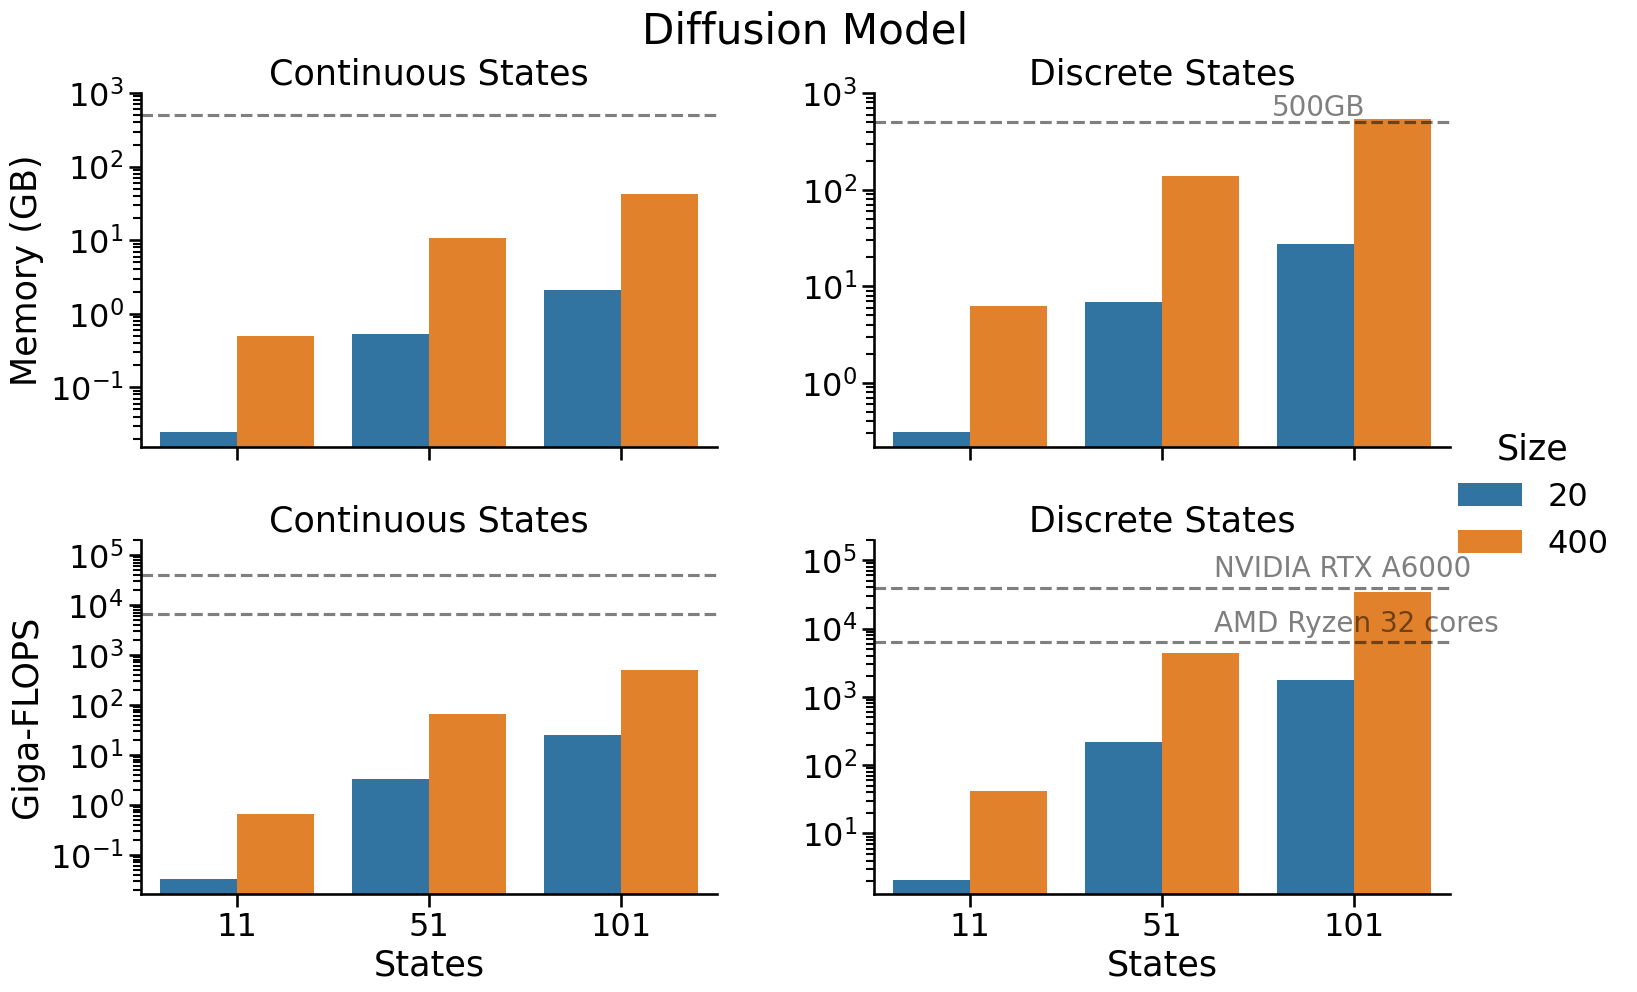

In [46]:
with sns.plotting_context("talk", font_scale=1.4):
    f = sns.catplot(
                df_memory_plot.query("Model=='Markov'").melt(id_vars=df_memory_plot.columns.drop(["bytes_accessed", "flops"]), var_name="func") \
                .assign(func = lambda df: df.func.map({"flops":"Giga-FLOPS", "bytes_accessed":"Memory (GB)"})) \
                .assign(I = lambda df: df.I.astype(str))
                ,
    x="States",
    y="value",
    col="state", #col_order=["Likelihood", "Likelihood Gradient"],
    hue="I",
    row="func",
    kind="bar", aspect=1.5, legend=True, sharey=False
    )
    f.figure.suptitle("Diffusion Model", y=1.01)
    f.legend.set_title("Size")
    f.set(yscale="log")
    f.axes[0,0].set_ylabel("Memory (GB)")
    f.axes[1,0].set_ylabel("Giga-FLOPS")
    f.set_xlabels("States")
    f.set_titles("{col_name} States")
    f.axes[0,0].axhline(y=500, ls="--", alpha=0.5, color="black")
    f.axes[0,1].axhline(y=500, ls="--", alpha=0.5, color="black")
    f.axes[0,1].text(x=1.57, y=580, s="500GB", alpha=0.5, color="black", size=20)
    #f.set_titles(col_template="")
    f.axes[1,0].axhline(y=38.71*1000, ls="--", alpha=0.5, color="black") #38.71 TFLOPS
    f.axes[1,0].axhline(y=6451.2, ls="--", alpha=0.5, color="black") # AMD Threadripper
    f.axes[1,1].axhline(y=38.71*1000, ls="--", alpha=0.5, color="black") #38.71 TFLOPS
    f.axes[1,1].axhline(y=6451.2, ls="--", alpha=0.5, color="black") # AMD Threadripper
    #f.legend.set_title("Participants")
    f.axes[1,1].text(y=38.71*1500, x=1.27, s="NVIDIA RTX A6000", alpha=0.5, size=20) #https://www.techpowerup.com/gpu-specs/rtx-a6000.c3686 
    f.axes[1,1].text(y=8900, x=1.27, s="AMD Ryzen 32 cores", alpha=0.5, size=20) #https://www.techpowerup.com/cpu-specs/ryzen-threadripper-pro-3975wx.c2315#:~:text=6%2C451.2,GFLOPS
    #f.set(ylim=(None, 100000))
    f.axes[0,0].set_ylim((None, 1000))
    f.axes[0,1].set_ylim((None, 1000))

    f.axes[1,0].set_ylim((None, 200000))
    f.axes[1,1].set_ylim((None, 200000))
    

In [47]:
arr = np.ones((400, 50, 425, 425))
(arr.itemsize * arr.size) / 1000000000

28.9